In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: For pretty scientific plots
try:
    import scienceplots
    plt.style.use(["science", "grid", "high-vis", "no-latex"])
except ImportError:
    plt.style.use("default")

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

In [ ]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from loveda import LoveDA  # adjust if you import differently

# Path setup (edit as needed)
root = "/content/drive/MyDrive/AML_Semantic_Segmentation/data"
list_path = "PIDNet/data/list/loveda/train_urban.lst"

# Enable augmentations
aug_type = color  # you can customize this!
aug_prob = 0.5

# Instantiate the dataset
dataset = LoveDA(
    root=root,
    list_path=list_path,
    num_classes=7,
    multi_scale=False,
    flip=False,  # handled by aug_type
    ignore_label=255,
    base_size=720,
    crop_size=(720, 720),
    augmentation_type=aug_type,
    aug_prob=aug_prob
)

# Color map from LoveDA
LOVEDA_COLORMAP = np.array([
    [0, 0, 0],         # 0: Ignore
    [255, 255, 255],   # 1: Background
    [255, 0, 0],       # 2: Building
    [0, 255, 0],       # 3: Road
    [0, 0, 255],       # 4: Water
    [255, 255, 0],     # 5: Barren
    [0, 255, 255],     # 6: Forest
    [255, 0, 255],     # 7: Agriculture
], dtype=np.uint8)

def colorize_mask(mask):
    mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, color in enumerate(LOVEDA_COLORMAP):
        mask_rgb[mask == cls] = color
    return mask_rgb

# Visualize a few samples
for i in range(5):
    img, mask, edge, size, name = dataset[i]
    # img is likely a tensor in CHW, normalized
    if isinstance(img, torch.Tensor):
        img = img.numpy()
    if img.shape[0] == 3:  # CHW to HWC
        img = np.transpose(img, (1, 2, 0))
    # Unnormalize if needed (ImageNet mean/std)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    # mask: numpy, shape H x W
    if isinstance(mask, torch.Tensor):
        mask = mask.numpy()
    mask_color = colorize_mask(mask)

    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title(f"Augmented Image: {name}")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(mask_color)
    plt.title("Segmentation Mask")
    plt.axis("off")
    plt.show()

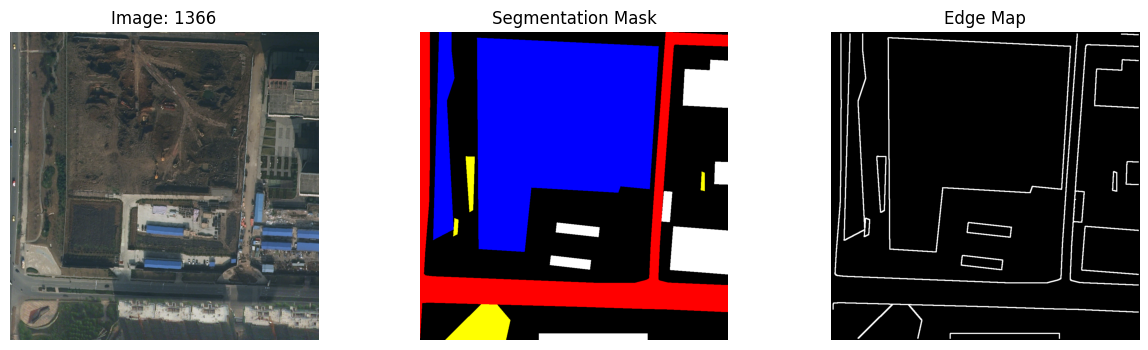

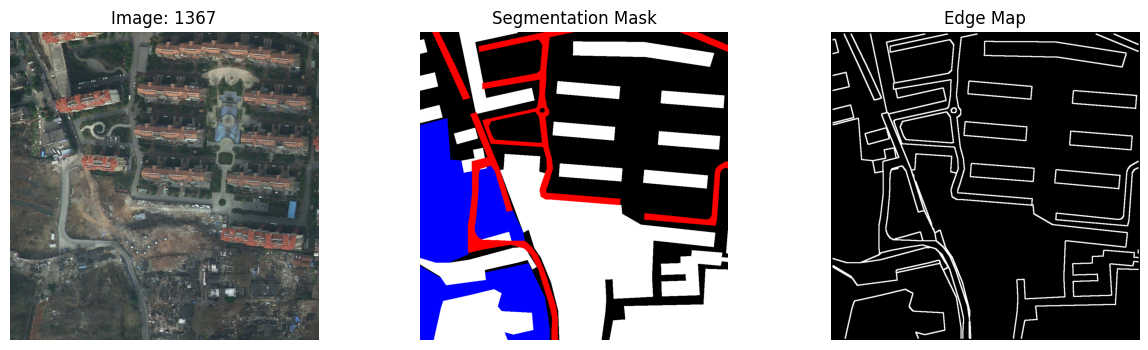

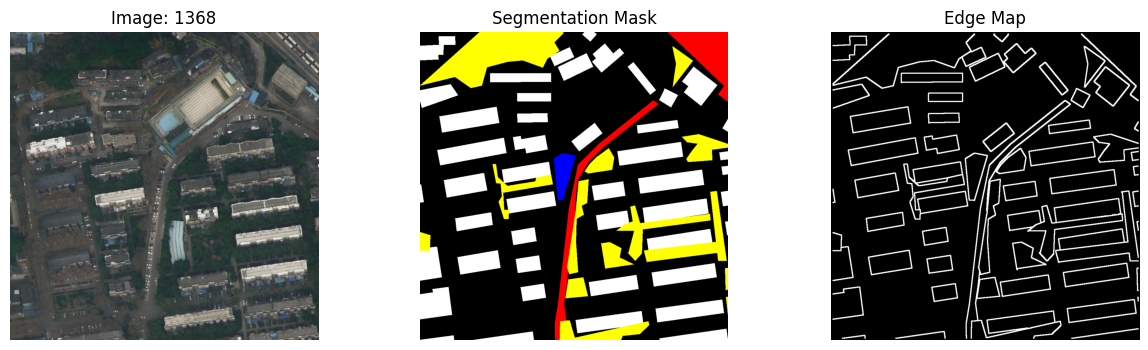

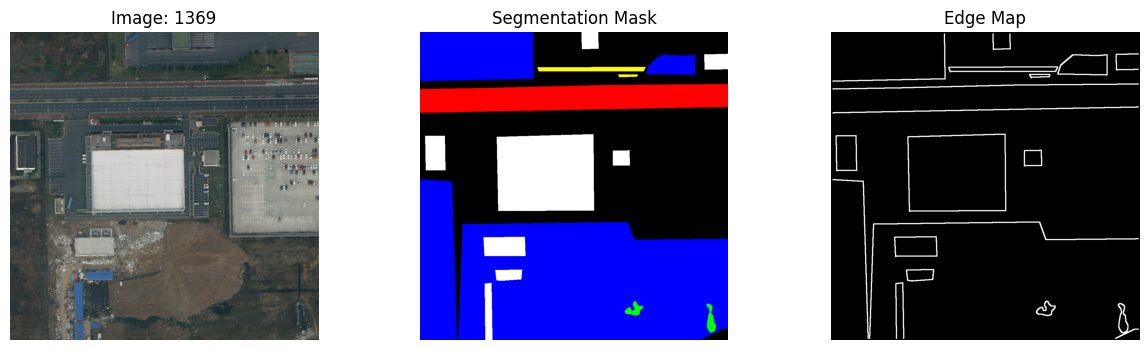

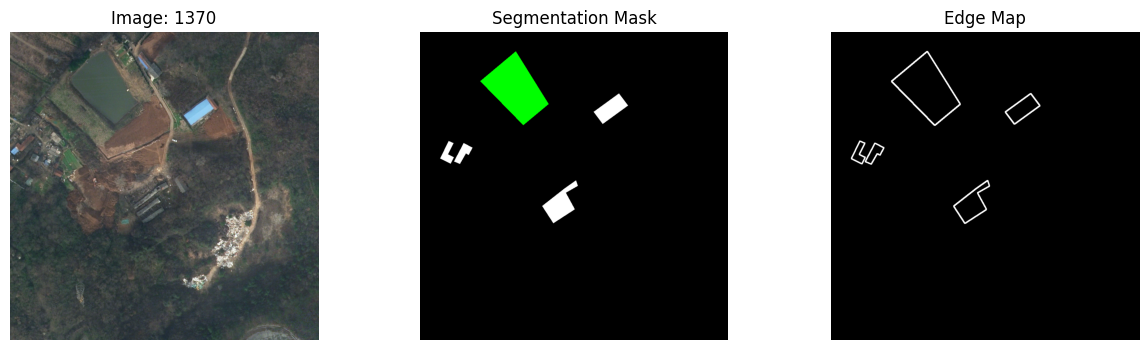

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from datasets.loveda import LoveDA  # adjust path/import as needed

# Path setup (edit as needed)
root = "/content/drive/MyDrive/AML_Semantic_Segmentation/"
list_path = "PIDNet/data/list/loveda/train_urban.lst"

# Augmentation options
aug_type = None
aug_prob = 0.5

# Instantiate the dataset
dataset = LoveDA(
    root=root,
    list_path=list_path,
    num_classes=7,
    multi_scale=False,
    flip=False,  # handled in aug_type
    ignore_label=255,
    base_size=720,
    crop_size=(720, 720),
    augmentation_type=aug_type,
    aug_prob=aug_prob
)

# Color map from LoveDA class (your loveda.py)
LOVEDA_COLORMAP = np.array([
    [0, 0, 0],         # 0: Ignore
    [255, 255, 255],   # 1: Background
    [255, 0, 0],       # 2: Building
    [0, 255, 0],       # 3: Road
    [0, 0, 255],       # 4: Water
    [255, 255, 0],     # 5: Barren
    [0, 255, 255],     # 6: Forest
    [255, 0, 255],     # 7: Agriculture
], dtype=np.uint8)

def colorize_mask(mask):
    mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, color in enumerate(LOVEDA_COLORMAP):
        mask_rgb[mask == cls] = color
    return mask_rgb

# Visualize a few samples
for i in range(5):
    img, mask, edge, size, name = dataset[i]
    # img: tensor CHW, normalized
    if isinstance(img, torch.Tensor):
        img = img.numpy()
    if img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))
    # Unnormalize
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    # mask: H x W, int
    if isinstance(mask, torch.Tensor):
        mask = mask.numpy()
    mask_color = colorize_mask(mask)

    # edge: H x W, float or int (0/1 or 0/255 or ignore_label)
    if isinstance(edge, torch.Tensor):
        edge = edge.numpy()
    # For visualization: show as white edges, black elsewhere (mask ignore_label as black)
    ignore_label = 255
    edge_vis = np.zeros_like(edge, dtype=np.uint8)
    edge_vis[edge == 1] = 255  # edge pixels as white
    edge_vis[edge == ignore_label] = 0    # ignore as black

    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Image: {name}")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(mask_color)
    plt.title("Segmentation Mask")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(edge_vis, cmap='gray')
    plt.title("Edge Map")
    plt.axis("off")
    plt.show()

Imports and Setup

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/AML_Semantic_Segmentation/data/PIDNet/data/list/loveda/'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AML_Semantic_Segmentation/data/PIDNet/data/list/loveda/'

# RUN

Install Dependencies

In [3]:
!pip install tensorboardX thop albumentations tqdm pyyaml yacs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.3 MB/s eta 0:00:00


Generate dataset list files

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet

!python -m datasets.loveda

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
<frozen runpy>:128: RuntimeWarning: 'datasets.loveda' found in sys.modules after import of package 'datasets', but prior to execution of 'datasets.loveda'; this may result in unpredictable behaviour


In [ ]:
import sys

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/')

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/datasets/')

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/tools/')

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/train.py --cfg configs/loveda/pidnet_loveda_3a.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3a
=> creating log/loveda/pidnet_small/pidnet_loveda_3a_2025-08-27-21-42
Namespace(cfg='configs/loveda/pidnet_loveda_3a.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
  TRAIN_SET_TARGET: 
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  LAMBDA_ADV1: 0.001
  LAMBDA_ADV2: 0.0002
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/train_adv_new.py --cfg configs/loveda/pidnet_loveda_4a.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_4a
=> creating log/loveda/pidnet_small/pidnet_loveda_4a_2025-08-28-14-46
Namespace(cfg='configs/loveda/pidnet_loveda_4a.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
  TRAIN_SET_TARGET: list/loveda/train_rural.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  LAMBDA_ADV: 0.001
  LAMBDA_ADV1: 0.001
  LAMBDA_ADV2: 0.0002
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
 

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/train_dacs.py --cfg configs/loveda/pidnet_loveda_4b.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_4b
=> creating log/loveda/pidnet_small/pidnet_loveda_4b_2025-08-27-18-50
Namespace(cfg='configs/loveda/pidnet_loveda_4b.yaml', seed=304, dacs_classmix_frac=0.5, dacs_loss_weight=0.1, dacs_pseudo_thr=0.968, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
  TRAIN_SET_TARGET: list/loveda/train_rural.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  LAMBDA_ADV1: 0.001
  LAMBDA_ADV2: 0.0002
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10


In [2]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/train_adv_multi.py --cfg configs/loveda/pidnet_loveda_4a.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_4a
=> creating log/loveda/pidnet_small/pidnet_loveda_4a_2025-09-01-10-36
Namespace(cfg='configs/loveda/pidnet_loveda_4a.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
  TRAIN_SET_TARGET: list/loveda/train_rural.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  LAMBDA_ADV: 0.001
  LAMBDA_ADV_AUX: 0.001
  LAMBDA_ADV_LIST: [0.0002, 0.001]
  LAMBDA_ADV_MAIN: 0.001
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/visualization.py --config configs/loveda/pidnet_loveda_3a.yaml --checkpoint output/loveda/pidnet_loveda_3a/best.pt --split val --output_dir visualizations --num_samples 10

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet


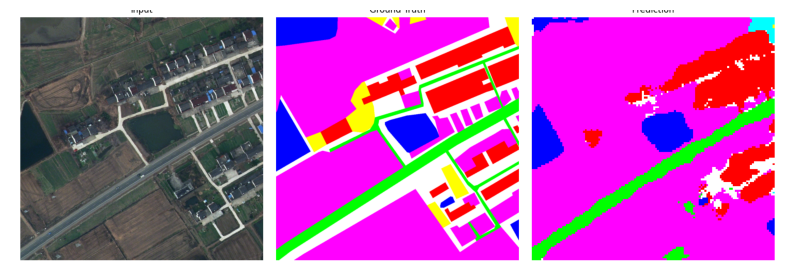

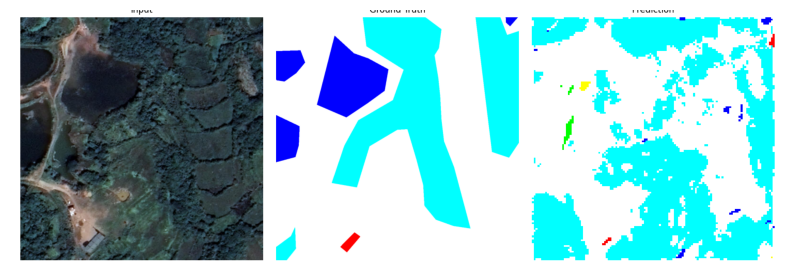

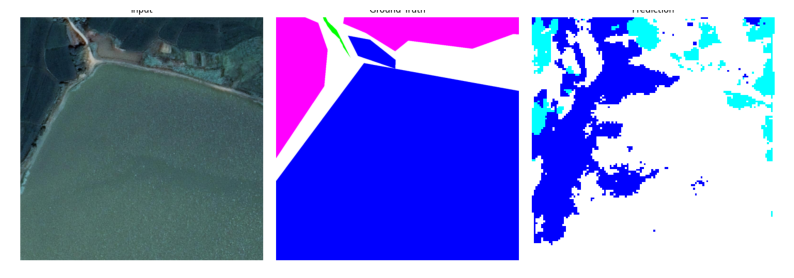

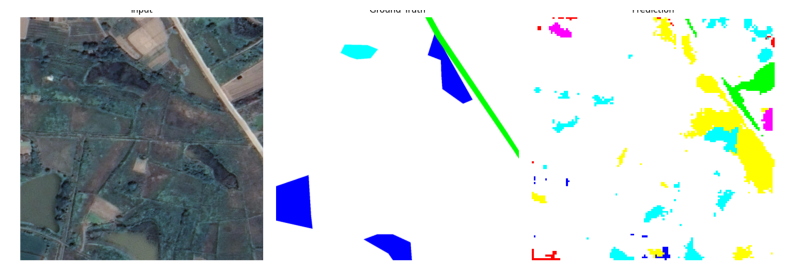

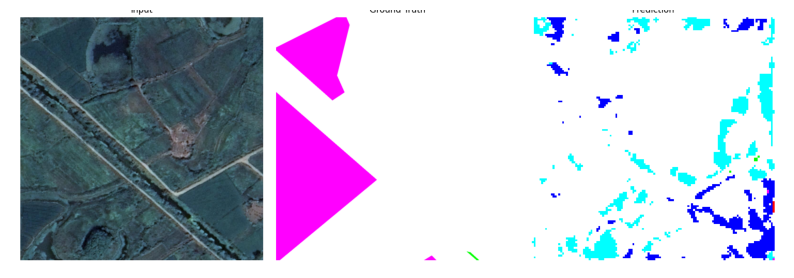

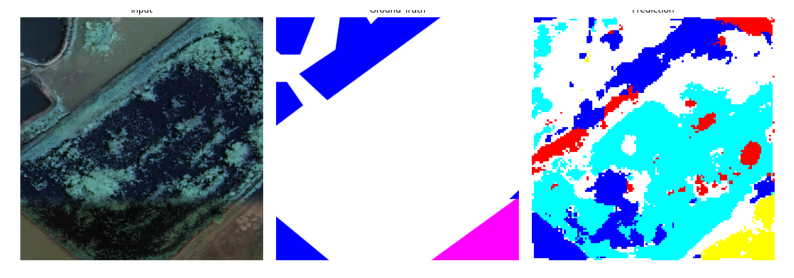

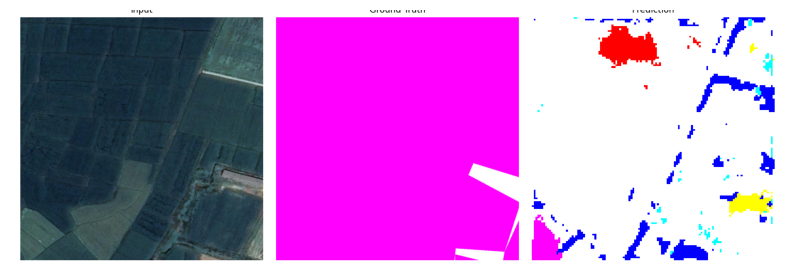

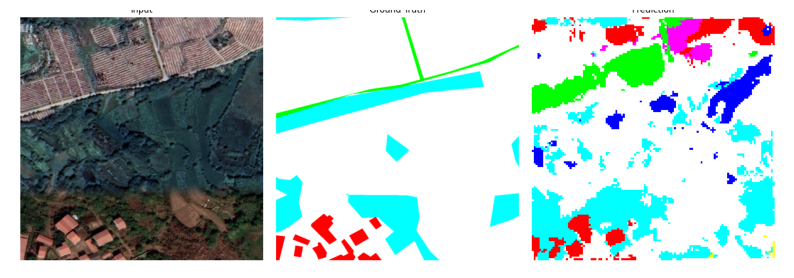

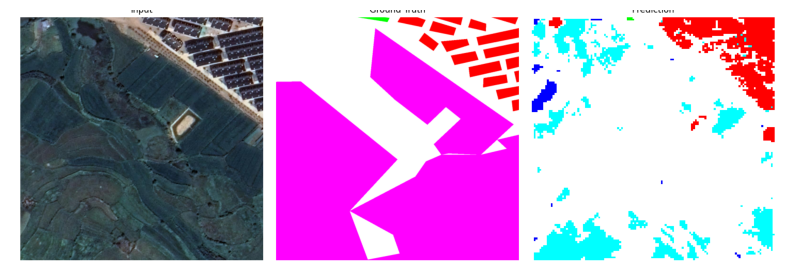

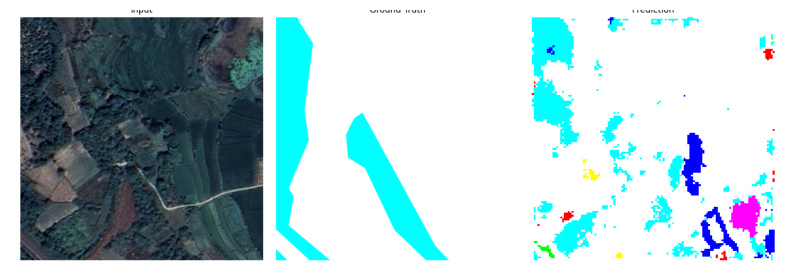

In [ ]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

vis_dir = 'visualizations'
imgs = sorted(glob.glob(f"{vis_dir}/*.png"))
for img_path in imgs[:10]:
    img = Image.open(img_path)
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()